# 01 — Exploratory Data Analysis (CICIDS2017)

**Objetivo del notebook**: caracterizar el dataset CICIDS2017 antes de cualquier
preprocesamiento. Establecer la línea base de qué hay, qué tan balanceado está,
qué problemas tiene a nivel de schema y de calidad de datos.

**Inputs**: parquets raw en `$RAW_DIR` (uno por día/ataque).

**Outputs**: ninguno persistido — este notebook es exploratorio. Las decisiones
sobre qué dropear, qué imputar y cómo reagrupar labels se toman en
`02_cleaning_preprocessing.ipynb`.

**Contexto académico**: CICIDS2017 (UNB) es un dataset estándar para benchmarking
de IDS basados en ML. Captura tráfico durante 5 días con ataques etiquetados:
botnet (Bot), brute force (FTP/SSH), DDoS, DoS (Hulk, GoldenEye, Slowloris,
Slowhttptest, Heartbleed), Infiltration, Port Scan, Web Attacks (XSS, SQLi,
Brute Force).

---

## Pasos

1. Carga de los 8 parquets raw.
2. Distribución de clases (overall + por día).
3. Inspección del schema (78 columnas).
4. Detección de NaN, Inf y problemas de encoding.
5. Resumen estadístico por clase.
6. Conclusiones que motivan el siguiente notebook.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')

# RAW_DIR: directorio con los 8 parquets crudos de CICIDS2017.
# Por defecto apunta a datasets/raw/ relativo al repo. Se puede sobreescribir
# con la variable de entorno RAW_DIR.
RAW_DIR = os.environ.get(
    'RAW_DIR',
    os.path.abspath(os.path.join(os.getcwd(), '..', 'datasets', 'raw'))
)
print(f"RAW_DIR = {RAW_DIR}")
print(f"Existe: {os.path.isdir(RAW_DIR)}")

RAW_DIR = /home/keppler-exe/Documentos/Maestria Proyecto Capston/ProyectoMIA/obj1_requisitos_datos/data/raw
Existe: True


## 1. Carga de parquets

Cada archivo cubre un día con uno o más tipos de tráfico. Los unificamos en
un solo DataFrame agregando una columna `Day` para preservar la procedencia
(útil después para el split estratificado por día).

In [2]:
files = sorted(f for f in os.listdir(RAW_DIR) if f.endswith('.parquet'))
print(f"Encontrados {len(files)} archivos:\n")

frames = []
for f in files:
    path = os.path.join(RAW_DIR, f)
    df = pd.read_parquet(path)
    day = f.split('-no-metadata')[0]
    df['Day'] = day
    frames.append(df)
    print(f"  {f:55s} {df.shape[0]:>8,} × {df.shape[1]:>3}")

df_all = pd.concat(frames, ignore_index=True)
print(f"\nTotal combinado: {df_all.shape[0]:,} filas × {df_all.shape[1]} cols")

Encontrados 8 archivos:

  Benign-Monday-no-metadata.parquet                        458,831 ×  79
  Botnet-Friday-no-metadata.parquet                        176,038 ×  79
  Bruteforce-Tuesday-no-metadata.parquet                   389,714 ×  79
  DDoS-Friday-no-metadata.parquet                          221,264 ×  79
  DoS-Wednesday-no-metadata.parquet                        584,991 ×  79
  Infiltration-Thursday-no-metadata.parquet                207,630 ×  79
  Portscan-Friday-no-metadata.parquet                      119,522 ×  79


  WebAttacks-Thursday-no-metadata.parquet                  155,820 ×  79



Total combinado: 2,313,810 filas × 79 cols


## 2. Distribución de clases

Antes de preocuparnos por features, conviene saber qué tan desbalanceado está
el dataset. Spoiler: muy desbalanceado (CICIDS2017 está dominado por tráfico
benigno y algunas clases de ataque tienen apenas decenas de ejemplos).

In [3]:
label_dist = df_all['Label'].value_counts()
total = len(df_all)
summary = pd.DataFrame({
    'count': label_dist,
    'pct': (label_dist / total * 100).round(3),
})
summary

,count,pct
Label,,
Benign,1977318,85.457
DoS Hulk,172846,7.470
DDoS,128014,5.533
DoS GoldenEye,10286,0.445
FTP-Patator,5931,0.256
DoS slowloris,5385,0.233
DoS Slowhttptest,5228,0.226
SSH-Patator,3219,0.139
PortScan,1956,0.085


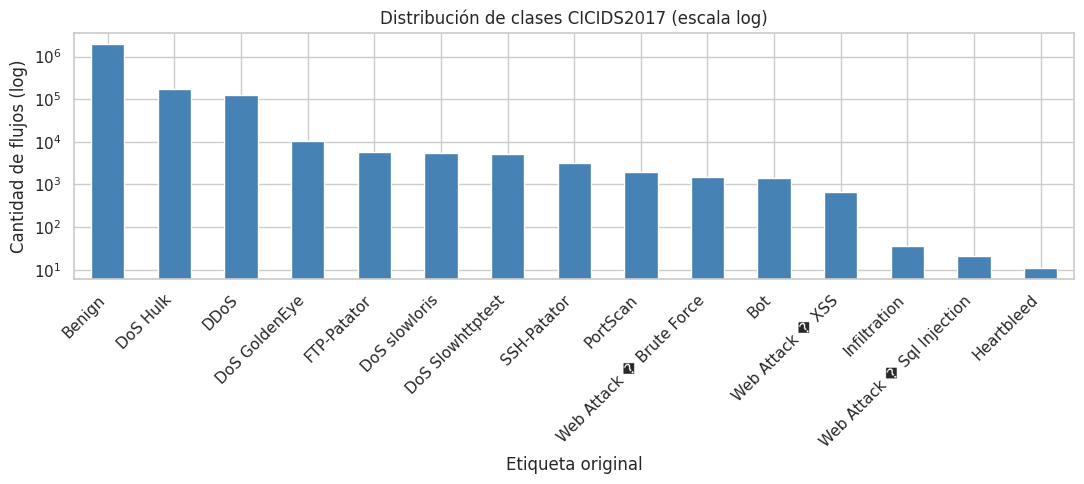

In [4]:
# Bar chart en escala log para que las clases minoritarias sean visibles
fig, ax = plt.subplots(figsize=(11, 5))
label_dist.plot(kind='bar', ax=ax, color='steelblue')
ax.set_yscale('log')
ax.set_ylabel('Cantidad de flujos (log)')
ax.set_xlabel('Etiqueta original')
ax.set_title('Distribución de clases CICIDS2017 (escala log)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observaciones inmediatas**:

- **Benign domina**: ~85% del tráfico. Cualquier modelo que prediga "Benign"
  por defecto tiene accuracy alta pero F1 bajo en ataques.
- **Heartbleed**: solo 11 muestras → casi imposible de aprender sin
  oversampling fuerte o exclusión.
- **Web Attacks** tienen un caracter raro (`�`) que indica problemas de
  encoding: el dataset original usa `–` (en-dash, U+2013) que se codificó mal.
  Hay que normalizar.
- **Infiltration**: 36 muestras, también problemático.

Decisiones que iremos tomando en notebooks siguientes:
- Mapear a 6 categorías (Benign, DoS, DDoS, Brute Force, Reconnaissance, Web Attack).
- Normalizar el encoding de Web Attacks.
- Considerar oversampling/undersampling para clases muy minoritarias o excluirlas
  si son insuficientes.

## 3. Distribución por día

CICIDS2017 captura cada tipo de ataque en un día específico. El split por
`Day` preserva esa estructura temporal en el train/val/test.

In [5]:
day_label = pd.crosstab(df_all['Day'], df_all['Label'], margins=True, margins_name='Total')
day_label

Label,Benign,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack � Brute Force,Web Attack � Sql Injection,Web Attack � XSS,Total
Day,,,,,,,,,,,,,,,,
Benign-Monday,458831,0,0,0,0,0,0,0,0,0,0,0,0,0,0,458831
Botnet-Friday,174601,1437,0,0,0,0,0,0,0,0,0,0,0,0,0,176038
Bruteforce-Tuesday,380564,0,0,0,0,0,0,5931,0,0,0,3219,0,0,0,389714
DDoS-Friday,93250,0,128014,0,0,0,0,0,0,0,0,0,0,0,0,221264
DoS-Wednesday,391235,0,0,10286,172846,5228,5385,0,11,0,0,0,0,0,0,584991
Infiltration-Thursday,207594,0,0,0,0,0,0,0,0,36,0,0,0,0,0,207630
Portscan-Friday,117566,0,0,0,0,0,0,0,0,0,1956,0,0,0,0,119522
WebAttacks-Thursday,153677,0,0,0,0,0,0,0,0,0,0,0,1470,21,652,155820
Total,1977318,1437,128014,10286,172846,5228,5385,5931,11,36,1956,3219,1470,21,652,2313810


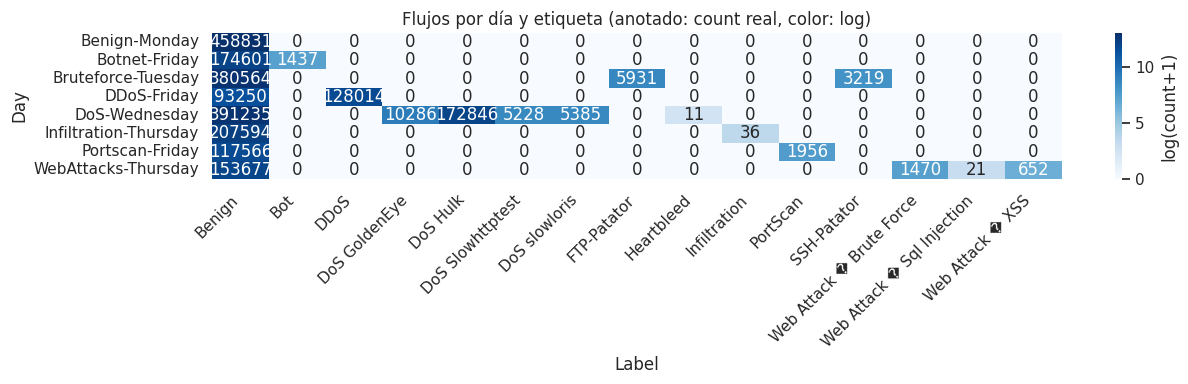

In [6]:
# Heatmap: filas = día, columnas = etiqueta, color = log(count)
pivot = pd.crosstab(df_all['Day'], df_all['Label'])
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(np.log1p(pivot), annot=pivot, fmt='d', cmap='Blues',
            cbar_kws={'label': 'log(count+1)'}, ax=ax)
ax.set_title('Flujos por día y etiqueta (anotado: count real, color: log)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Schema y tipos

CICIDS2017 trae 77 features de flujo extraídas con CICFlowMeter, más una
columna `Label`. Acá inspeccionamos los tipos de datos para detectar
columnas numéricas almacenadas como string, columnas constantes obvias, etc.

In [7]:
dtype_summary = df_all.dtypes.value_counts()
print(f"Tipos de datos:\n{dtype_summary}\n")
print(f"Columnas object (strings): {[c for c in df_all.columns if df_all[c].dtype == 'object']}")

Tipos de datos:
int32      26
float32    22
int8       19
int16       7
float64     2
str         2
int64       1
Name: count, dtype: int64

Columnas object (strings): []


In [8]:
# Estadísticas básicas de las features numéricas
numeric_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
print(f"Features numéricas: {len(numeric_cols)}")

stats = df_all[numeric_cols].describe().T[['mean','std','min','max']]
# Detectar columnas con varianza nula (constantes)
zero_var = stats[stats['std'] == 0].index.tolist()
print(f"\nColumnas con varianza 0 (candidatas a drop): {len(zero_var)}")
for c in zero_var:
    print(f"  - {c} (todas las filas valen {df_all[c].iloc[0]})")

Features numéricas: 77



Columnas con varianza 0 (candidatas a drop): 8
  - Bwd PSH Flags (todas las filas valen 0)
  - Bwd URG Flags (todas las filas valen 0)
  - Fwd Avg Bytes/Bulk (todas las filas valen 0)
  - Fwd Avg Packets/Bulk (todas las filas valen 0)
  - Fwd Avg Bulk Rate (todas las filas valen 0)
  - Bwd Avg Bytes/Bulk (todas las filas valen 0)
  - Bwd Avg Packets/Bulk (todas las filas valen 0)
  - Bwd Avg Bulk Rate (todas las filas valen 0)


## 5. NaN, Inf y outliers extremos

Las features de tasa (`Flow Bytes/s`, `Flow Packets/s`) suelen tener valores
infinitos cuando la duración del flujo es 0. Hay que detectarlos.

In [9]:
nan_per_col = df_all[numeric_cols].isna().sum()
nan_per_col = nan_per_col[nan_per_col > 0].sort_values(ascending=False)
print(f"Columnas con NaN: {len(nan_per_col)}")
if len(nan_per_col):
    print(nan_per_col)
else:
    print("(ninguna)")

Columnas con NaN: 0
(ninguna)


In [10]:
# Columnas con inf
inf_per_col = (df_all[numeric_cols] == np.inf).sum() + (df_all[numeric_cols] == -np.inf).sum()
inf_per_col = inf_per_col[inf_per_col > 0].sort_values(ascending=False)
print(f"Columnas con Inf: {len(inf_per_col)}")
if len(inf_per_col):
    print(inf_per_col)
else:
    print("(ninguna)")

Columnas con Inf: 0
(ninguna)


## 6. Distribución de algunas features clave por clase

Visualizamos un par de features intuitivamente relevantes para distinguir
ataques de tráfico benigno: `Flow Duration`, `Total Fwd Packets`,
`Flow Bytes/s`.

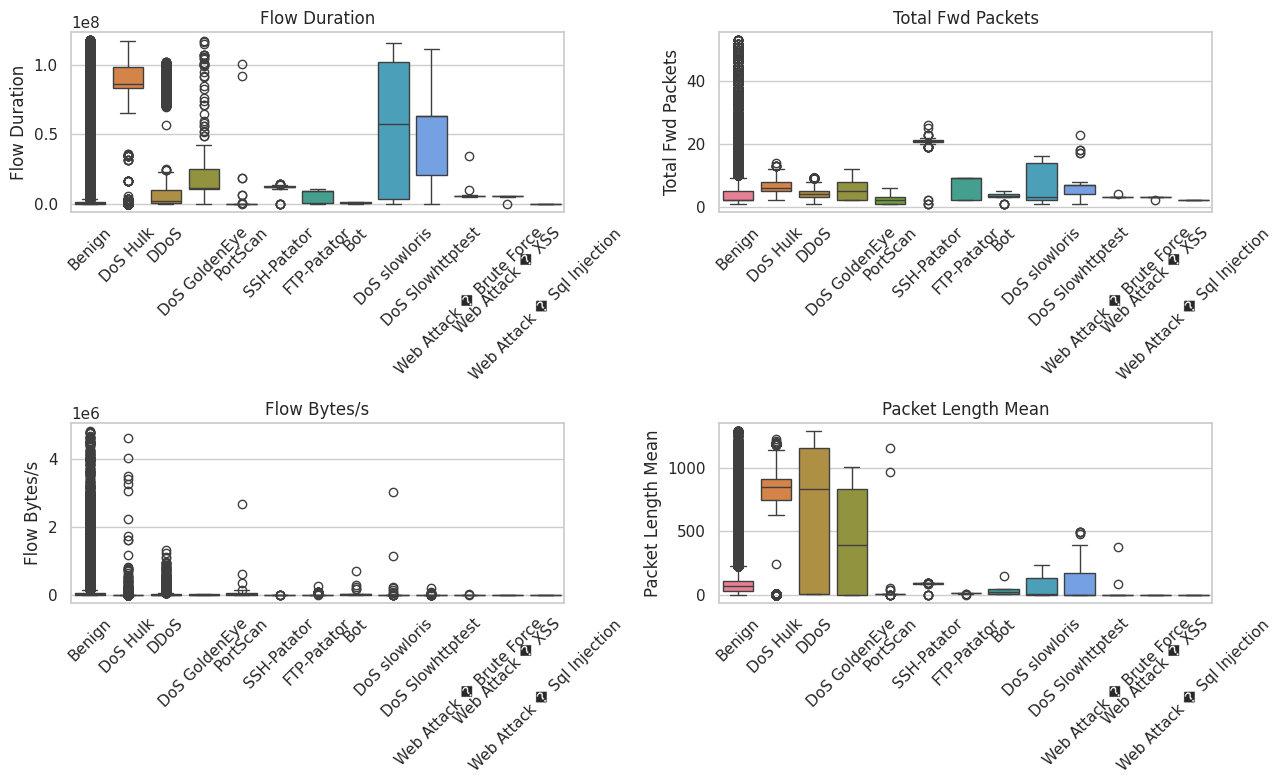

In [11]:
# Sample para que los plots no exploten
sample = df_all.sample(n=min(50_000, len(df_all)), random_state=42)

key_features = ['Flow Duration', 'Total Fwd Packets', 'Flow Bytes/s', 'Packet Length Mean']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat in zip(axes.flat, key_features):
    data = sample[[feat, 'Label']].replace([np.inf, -np.inf], np.nan).dropna()
    # Recortar al percentil 99 para que outliers no oculten la distribución
    upper = data[feat].quantile(0.99)
    data = data[data[feat] <= upper]
    sns.boxplot(data=data, x='Label', y=feat, ax=ax, hue='Label', legend=False)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Conclusiones

**Lo que aprendimos**:

1. **2.3M flujos** en 8 archivos, 77 features numéricas + Label.
2. **Distribución muy desbalanceada**: Benign ≈ 85%, varias clases con <100
   muestras.
3. **Encoding roto** en Web Attacks (`–` corrupto).
4. **8 features candidatas a drop por varianza 0** (constantes en todo el
   dataset, no aportan señal).
5. **Posibles Inf** en features de tasa cuando `Flow Duration = 0`.
6. **CICFlowMeter es bidireccional**: muchas features tienen pares
   `Fwd_*`/`Bwd_*` correlacionados — candidatos a colinealidad.

**Próximo notebook (02)**: aplicar limpieza, normalizar nombres, mapear labels
a 6 categorías, eliminar duplicados (la bitácora menciona ~28% de duplicados),
y producir un parquet "clean" para los siguientes notebooks.